In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
def read_parquet_file(file_name):
    df = pd.read_parquet(file_name, engine="fastparquet")
    print(file_name)
    print(df.head())
    print('########################################################################')
    print('info')
    print(df.info())
    return df

### Read the sales data and show some info and descriptive statistics:

In [4]:
sales = read_parquet_file('20260218_144523_sales_data.parquet')

20260218_144523_sales_data.parquet
        date         category_name  item_id  sold_quantity  price  store_id
0 2025-04-01     Angebot Brötchen       139           15.0    0.0         0
1 2025-04-01  Angebot Feinbäckerei      138           28.0    0.0         0
2 2025-04-01  Angebot Heißgetränke      106           25.0    0.0         0
3 2025-04-01  Angebot Heißgetränke      539            5.0    1.4         0
4 2025-04-01         Angebot Snack      176            1.0    0.0         0
########################################################################
info
<class 'pandas.DataFrame'>
RangeIndex: 713637 entries, 0 to 713636
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   date           713637 non-null  datetime64[ns]
 1   category_name  713637 non-null  object        
 2   item_id        713637 non-null  int64         
 3   sold_quantity  713637 non-null  float64       
 4   price          

In [5]:
sales.describe()

,date,item_id,sold_quantity,price,store_id
count,713637,713637.000000,713637.000000,696648.000000,713637.000000
mean,2025-05-15 16:04:01.050282240,262.957623,15.845915,2.747405,30.802189
min,2025-04-01 00:00:00,0.000000,-1.000000,-22.000000,0.000000
25%,2025-04-24 00:00:00,67.000000,1.000000,1.100000,14.000000
50%,2025-05-16 00:00:00,220.000000,4.000000,2.600000,30.000000
75%,2025-06-07 00:00:00,449.000000,12.000000,3.800000,46.000000
max,2025-06-30 00:00:00,676.000000,2425.000000,115.000000,83.000000
std,NaN,216.843557,60.843418,2.129056,19.148652




#### Investigate the missing 'price' and negative 'sold_quantity'
#### 1. Missing price



         date category_name  item_id  sold_quantity  price  store_id
28 2025-04-01          Brot      315            0.0    NaN         0
39 2025-04-01          Brot      338            0.0    NaN         0
41 2025-04-01          Brot      340            0.0    NaN         0
43 2025-04-01          Brot      342            0.0    NaN         0
77 2025-04-01      Brötchen       52            0.0    NaN         0
###################################################################
                                date       item_id  sold_quantity  price  \
count                          16989  16989.000000        16989.0    0.0   
mean   2025-05-15 17:22:58.845135104    246.083996            0.0    NaN   
min              2025-04-01 00:00:00     51.000000            0.0    NaN   
25%              2025-04-24 00:00:00    248.000000            0.0    NaN   
50%              2025-05-16 00:00:00    256.000000            0.0    NaN   
75%              2025-06-07 00:00:00    340.000000            

Text(0.5, 1.0, 'distribution of missing price by product category')

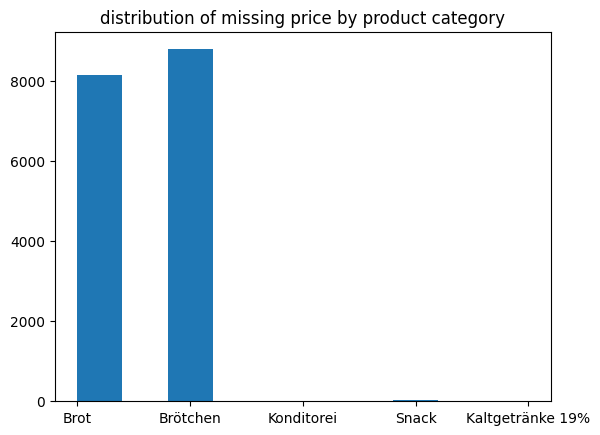

In [6]:
missing_price = sales[sales['price'].isna()]
print(missing_price.head())
print('###################################################################')
print(missing_price.describe())
print('###################################################################')
print('Number of missing price: ', len(missing_price))
print('###################################################################')
#print(missing_price['store_id'].value_counts())
plt.hist(missing_price['category_name'])
plt.title('distribution of missing price by product category')

#### Sold quantity is always 0 when price is missing -> We could delete these lines
delete the missing prices

In [7]:
sales.isna().any()

date             False
category_name    False
item_id          False
sold_quantity    False
price             True
store_id         False
dtype: bool

In [8]:
sales = sales.dropna(axis = 0)

#### Missing prices are removed

In [9]:
sales.isna().any()

date             False
category_name    False
item_id          False
sold_quantity    False
price            False
store_id         False
dtype: bool

#### 2. negative sold quantities

<Axes: xlabel='category_name', ylabel='sold_quantity'>

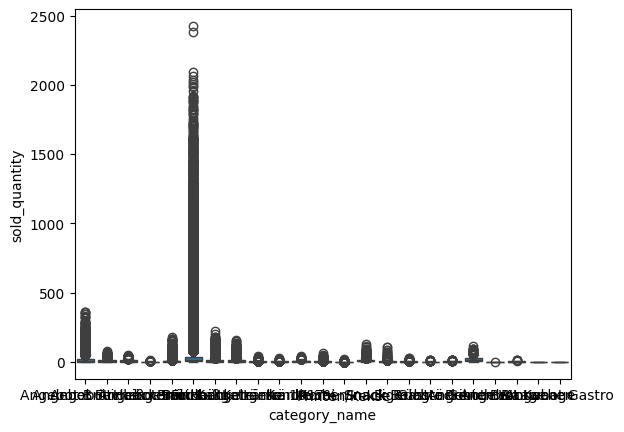

In [12]:
sns.boxplot(x = 'category_name', y = 'sold_quantity', data = sales)

In [36]:
print(sales.loc[(sales['category_name'] == 'Brötchen') & (sales['store_id'] == 4)])

             date category_name  item_id  sold_quantity  price  store_id
634    2025-04-01      Brötchen        0          366.0   0.48         4
635    2025-04-01      Brötchen        1            0.0   0.52         4
636    2025-04-01      Brötchen        2            6.0   0.60         4
637    2025-04-01      Brötchen        5            0.0   0.95         4
638    2025-04-01      Brötchen        6            0.0   1.10         4
...           ...           ...      ...            ...    ...       ...
706121 2025-06-30      Brötchen      250            0.0    NaN         4
706122 2025-06-30      Brötchen      251            0.0    NaN         4
706123 2025-06-30      Brötchen      252            0.0    NaN         4
706124 2025-06-30      Brötchen      253            0.0    NaN         4
706125 2025-06-30      Brötchen      256            0.0    NaN         4

[4992 rows x 6 columns]


#### The table above shows that Brötchen could have different prices

In [ ]:
holidays = read_parquet_file('20260218_144523_holidays.parquet')

20260218_144523_holidays.parquet
  zipcode subdivision_code       date holiday_name    holiday_type
0   41812            DE-NW 2025-04-01   Zuckerfest     special_day
1   41812            DE-NW 2025-04-02   Zuckerfest     special_day
2   41812            DE-NW 2025-04-12  Osterferien  school_holiday
3   41812            DE-NW 2025-04-13  Osterferien  school_holiday
4   41812            DE-NW 2025-04-13  Palmsonntag     special_day
info
<class 'pandas.DataFrame'>
RangeIndex: 1301 entries, 0 to 1300
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   zipcode           1301 non-null   object        
 1   subdivision_code  1301 non-null   object        
 2   date              1301 non-null   datetime64[ns]
 3   holiday_name      1301 non-null   object        
 4   holiday_type      1301 non-null   object        
dtypes: datetime64[ns](1), object(4)
memory usage: 50.9+ KB
None


In [6]:
stores = read_parquet_file('20260218_144523_stores.parquet')


20260218_144523_stores.parquet
  subdivision_code country_code zipcode  average_weekly_revenue_Q1  store_id
0            DE-NW           DE   52062               21448.248159         0
1            DE-NW           DE   52224               17844.961211         1
2            DE-NW           DE   52134               12808.989643         2
3            DE-NW           DE   52062                7635.616974         3
4            DE-NW           DE   52222               21000.922881         4
info
<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   subdivision_code           84 non-null     object 
 1   country_code               84 non-null     object 
 2   zipcode                    84 non-null     object 
 3   average_weekly_revenue_Q1  84 non-null     float64
 4   store_id                   84 non-null     int64  
dtypes: float64(1),

In [7]:
weather = read_parquet_file('20260218_144523_weather.parquet')

20260218_144523_weather.parquet
        date   time zipcode  temperature  wind_speed  wind_degree wind_dir  \
0 2025-04-01  20:00   41812         10.0        16.0         79.0      ENE   
1 2025-04-01  21:00   41812          9.0        16.0         75.0      ENE   
2 2025-04-01  22:00   41812          9.0        18.0         71.0      ENE   
3 2025-04-01  23:00   41812          8.0        20.0         70.0      ENE   
4 2025-04-01  00:00   41812          6.0        10.0         52.0       NE   

   weather_code weather_description  precip  ...  chanceofremdry  \
0           113               Clear     0.0  ...             0.0   
1           113               Clear     0.0  ...             0.0   
2           113               Clear     0.0  ...             0.0   
3           113               Clear     0.0  ...             0.0   
4           113               Clear     0.0  ...             0.0   

   chanceofwindy  chanceofovercast  chanceofsunshine  chanceoffrost  \
0            0.0   